# Brainfood EEG Deep Learning Workshop

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import torch
from mne_bids import print_dir_tree
from torch import nn
from torch.utils.data import DataLoader, Dataset

## Data Overview

In [ ]:
# Download and unzip the BNCI2014 dataset from https://ww2.nemar.org/dataset/nm000139
# Then configure the path here:
bids_root = Path("data/BNCI_2014")

In [ ]:
print_dir_tree(bids_root)

### Load and preprocess an individual file

In [ ]:
path = next(bids_root.glob("sub-1/ses-0train/eeg/*run-0_eeg.bdf"))
raw = mne.io.read_raw_bdf(path, preload=True, verbose=False)

In [ ]:
raw

<RawBDF | sub-1_ses-0train_task-imagery_run-0_eeg.bdf, 22 x 96750 (387.0 s), ~16.3 MiB, data loaded>

Using matplotlib as 2D backend.


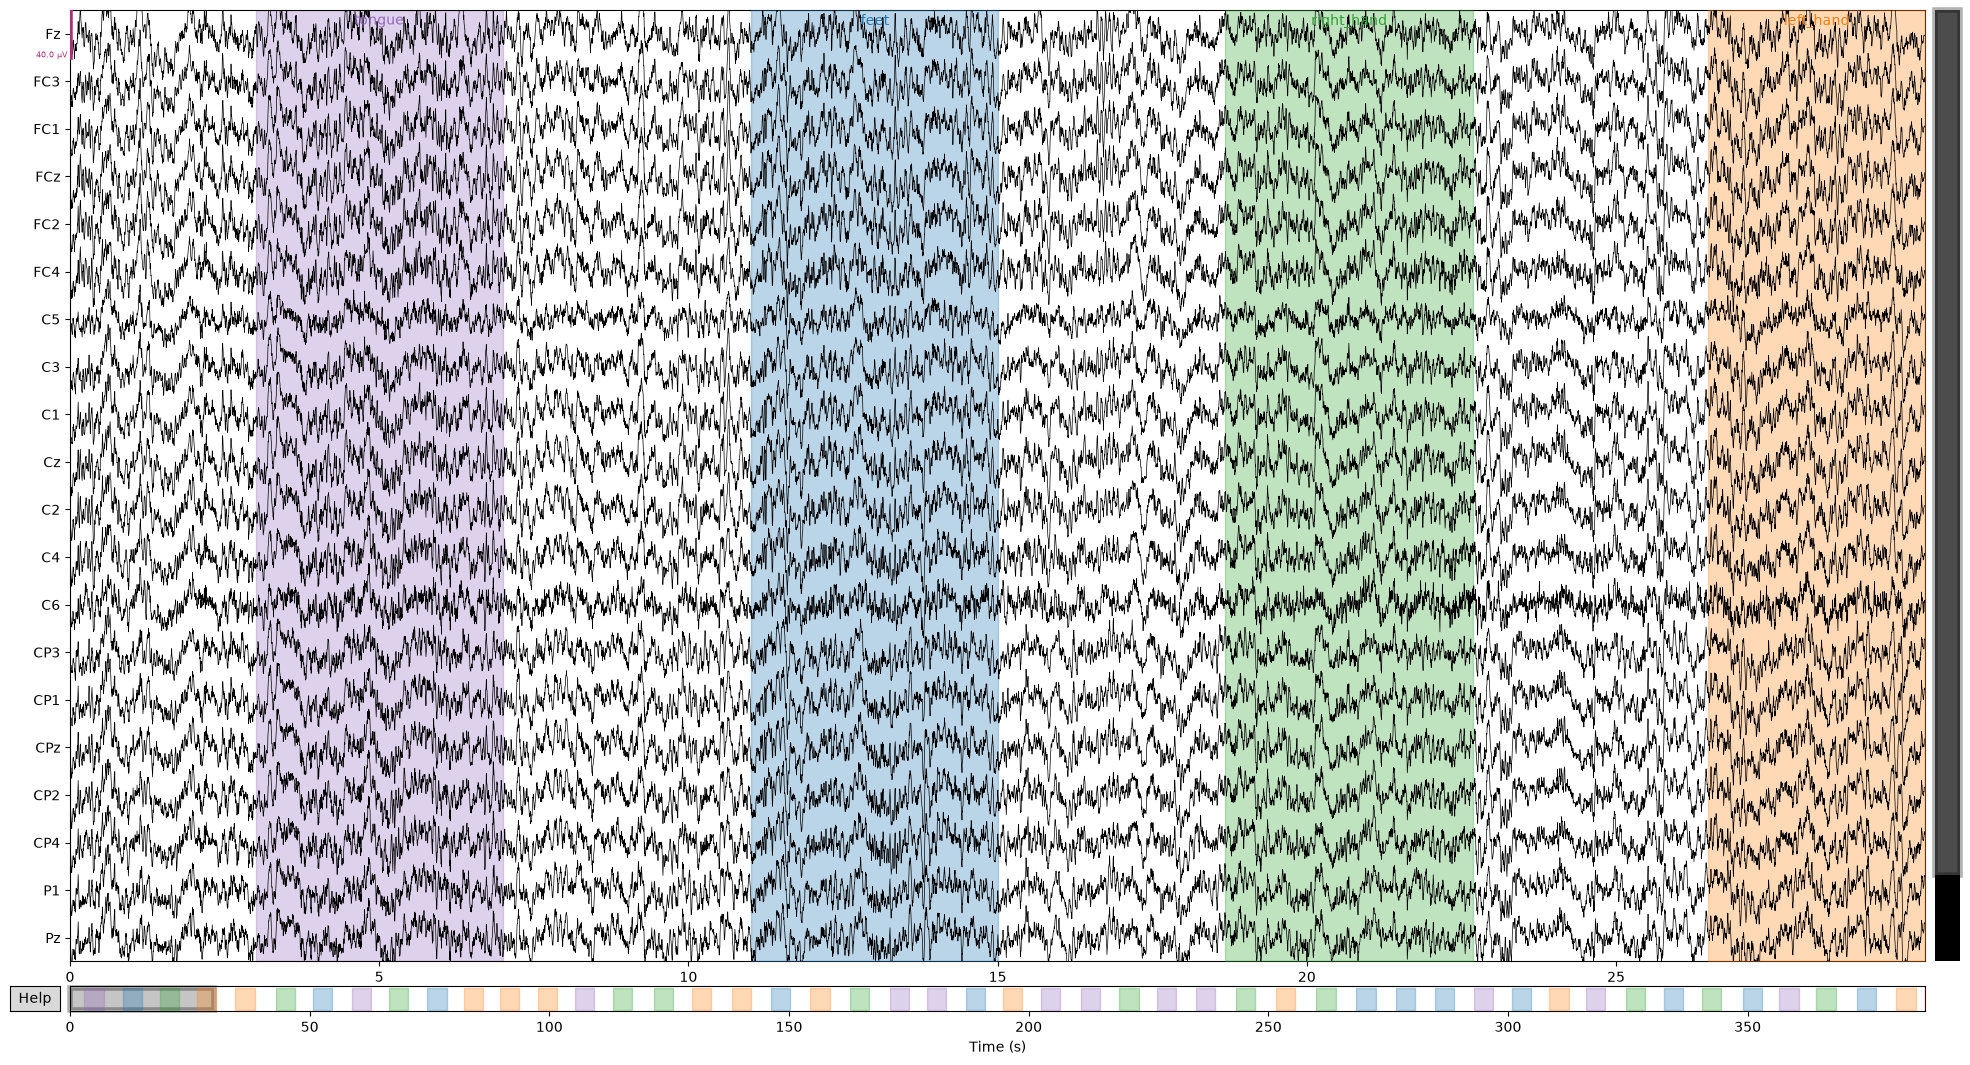

In [ ]:
fig = raw.plot(duration=30)

In [ ]:
raw.annotations.to_data_frame().head()

,onset,duration,description
0,2008-01-01 00:00:03.000,4.0,tongue
1,2008-01-01 00:00:11.012,4.0,feet
2,2008-01-01 00:00:18.684,4.0,right_hand
3,2008-01-01 00:00:26.492,4.0,left_hand
4,2008-01-01 00:00:34.524,4.0,left_hand


In [ ]:
# Basic preprocessing
raw.filter(1.0, 50.0, verbose=False)
raw.notch_filter(50, verbose=False)
raw.resample(100, verbose=False)
raw.set_eeg_reference(ref_channels="average", verbose=False)

<RawBDF | sub-1_ses-0train_task-imagery_run-0_eeg.bdf, 22 x 38700 (387.0 s), ~6.5 MiB, data loaded>

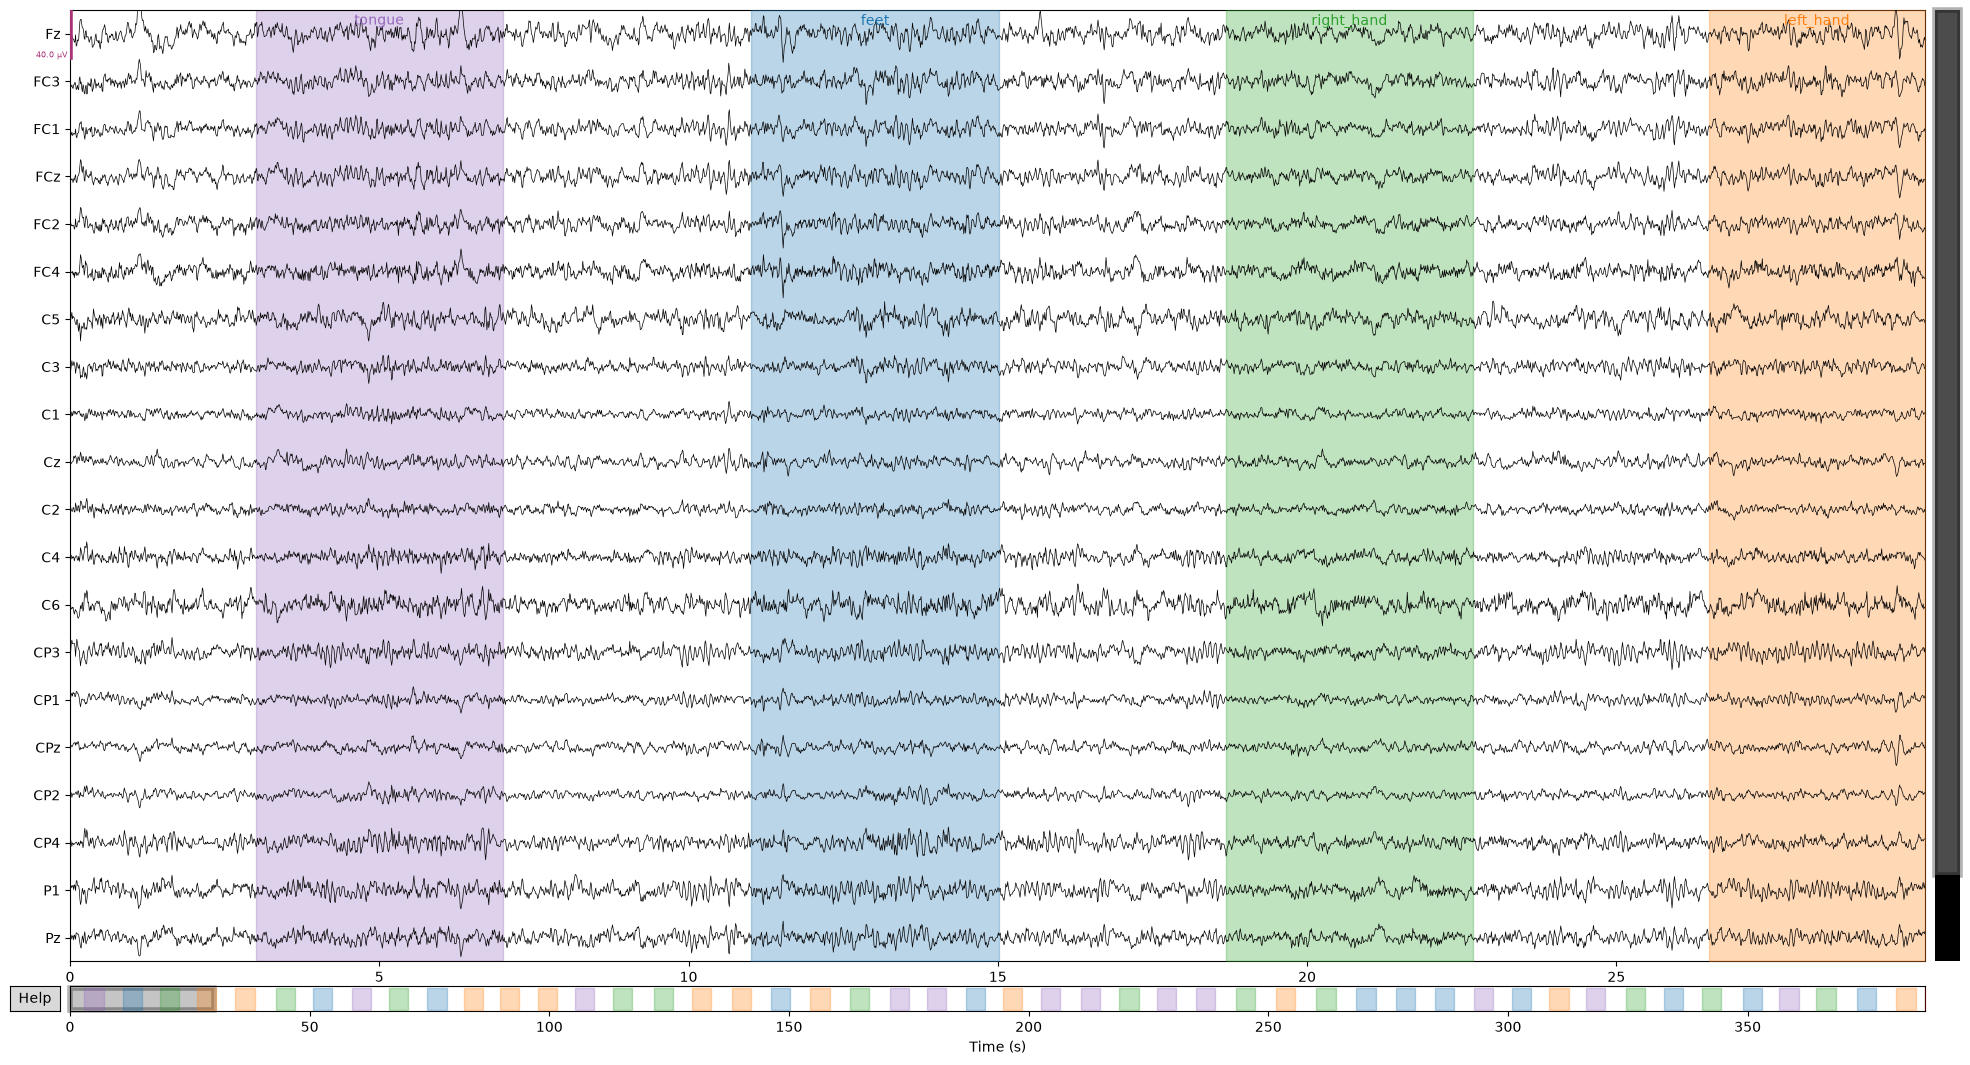

In [ ]:
fig = raw.plot(duration=30)

## Data Loading

### Implement Dataset Class

In [ ]:
class BNCIDataset(Dataset):
    def __init__(
        self,
        file_paths: list[str | Path],  # list of paths to EEG recordings
        l_freq: float | None = 1.0,  # low cutoff frequency for bandpass filter
        h_freq: float | None = 50.0,  # high cutoff frequency for bandpass filter
        notch_freq: float = 50.0,  # notch filter frequency
        sfreq: float = 100,  # target sampling frequency
        tmin: float = 0.0,  # epoch start relative to cue
        tmax: float = 4.0,  # epoch end relative to cue
    ):

        all_X, all_y = [], []
        for path in file_paths:
            # Load data from file
            raw = mne.io.read_raw_bdf(path, preload=True, verbose=False)

            # Preprocess
            raw.filter(l_freq, h_freq, verbose=False)
            raw.notch_filter(notch_freq, verbose=False)
            raw.resample(sfreq, verbose=False)
            raw.set_eeg_reference(ref_channels="average", verbose=False)

            # Extract events
            events, event_id = mne.events_from_annotations(raw, verbose=False)

            # Create epochs from left and right hand trials
            epochs = mne.Epochs(
                raw,
                events,
                event_id={
                    "left_hand": event_id["left_hand"],
                    "right_hand": event_id["right_hand"],
                },
                tmin=tmin,
                tmax=tmax - 1.0 / raw.info["sfreq"],  # exclude the last sample
                baseline=None,
                preload=True,
                verbose=False,
            )

            # Convert to numpy and map labels to left=0, right=1
            X = epochs.get_data(copy=True).astype("float32")
            y = (epochs.events[:, 2] == event_id["right_hand"]).astype(np.int64)

            # Scale so values are roughly in [-1, 1]
            X *= 1e5

            all_X.append(X)
            all_y.append(y)

        # Concatenate and convert into torch tensors
        self.X = torch.from_numpy(np.concatenate(all_X, axis=0))
        self.y = torch.from_numpy(np.concatenate(all_y, axis=0))

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


### Create Datasets

In [ ]:
# Get file paths for train, validation, and test sets
train_paths = sorted(bids_root.glob("sub-1/ses-0train/eeg/*_run-[0-4]_eeg.bdf"))
val_paths = sorted(bids_root.glob("sub-1/ses-0train/eeg/*_run-5_eeg.bdf"))
test_paths = sorted(bids_root.glob("sub-1/ses-1test/eeg/*_eeg.bdf"))

print(
    f"Found {len(train_paths)} train files, "
    f"{len(val_paths)} validation files, and {len(test_paths)} test files."
)

# Create datasets
train_dataset = BNCIDataset(train_paths)
val_dataset = BNCIDataset(val_paths)
test_dataset = BNCIDataset(test_paths)

print(
    f"Train: {len(train_dataset)} trials | Val: {len(val_dataset)} trials | Test: {len(test_dataset)} trials"
)

Found 5 train files, 1 validation files, and 6 test files.
Train: 120 trials | Val: 24 trials | Test: 144 trials


In [ ]:
train_dataset[0]

(tensor([[ 0.0859,  0.5302,  0.6597,  ..., -0.6764, -0.4638, -0.5668],
         [ 0.1861,  0.2426,  0.5455,  ..., -0.4112, -0.5247, -0.3748],
         [ 0.2307,  0.5631,  0.6418,  ..., -0.3800, -0.2714, -0.1728],
         ...,
         [ 0.2142, -0.1145, -0.3497,  ...,  0.3101,  0.1689, -0.0490],
         [-0.1930, -0.5604, -0.5491,  ...,  0.1518, -0.0410, -0.1419],
         [ 0.3973,  0.0432, -0.1691,  ...,  0.1880, -0.2521, -0.4051]]),
 tensor(1))

### Create dataloaders

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

## Model Creation

In [ ]:
from braindecode.models import ShallowFBCSPNet

In [ ]:
n_channels = train_dataset.X.shape[1]
n_times = train_dataset.X.shape[2]

model = ShallowFBCSPNet(
    n_chans=n_channels,
    n_outputs=2,
    n_times=n_times,
    n_filters_time=16,
    n_filters_spat=16,
)

print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Layer (type (var_name):depth-idx)             Input Shape               Output Shape              Param #                   Kernel Shape
ShallowFBCSPNet (ShallowFBCSPNet)             [1, 22, 400]              [1, 2]                    --                        --
├─Ensure4d (ensuredims): 1-1                  [1, 22, 400]              [1, 22, 400, 1]           --                        --
├─Rearrange (dimshuffle): 1-2                 [1, 22, 400, 1]           [1, 1, 400, 22]           --                        --
├─CombinedConv (conv_time_spat): 1-3          [1, 1, 400, 22]           [1, 16, 376, 1]           6,048                     --
├─BatchNorm2d (bnorm): 1-4                    [1, 16, 376, 1]           [1, 16, 376, 1]           32                        --
├─Square (conv_nonlin_exp): 1-5               [1, 16, 376, 1]           [1, 16, 376, 1]           --                        --
├─AvgPool2d (pool): 1-6                       [1, 16, 376, 1]           [1, 16, 21, 1]            -- 

## Training

In [ ]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.1)
n_epochs = 300

train_accs, val_accs = [], []
train_losses, val_losses = [], []
for epoch in range(n_epochs):
    # Train
    model.train()
    correct, total, loss_sum = 0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        batch_size = len(y_batch)
        loss_sum += loss.item() * batch_size
        correct += (logits.argmax(1) == y_batch).sum().item()
        total += batch_size

    train_accs.append(correct / total)
    train_losses.append(loss_sum / total)

    # Evaluate
    model.eval()
    correct_v, total_v, loss_sum_v = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            batch_size = len(y_batch)
            loss_sum_v += loss.item() * batch_size
            correct_v += (logits.argmax(1) == y_batch).sum().item()
            total_v += batch_size

    val_accs.append(correct_v / total_v)
    val_losses.append(loss_sum_v / total_v)

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1:3d} | "
            f"Train acc: {train_accs[-1]:.2%}, loss: {train_losses[-1]:.4f} | "
            f"Val acc: {val_accs[-1]:.2%}, loss: {val_losses[-1]:.4f}"
        )

In [ ]:
# Plot training and validation loss and accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, train_values, val_values, ylabel in [
    (axes[0], train_losses, val_losses, "Loss"),
    (axes[1], train_accs, val_accs, "Accuracy"),
]:
    for values, label, color in [
        (train_values, "Train", "tab:blue"),
        (val_values, "Validation", "tab:orange"),
    ]:
        epochs = np.arange(1, len(values) + 1)
        ax.plot(epochs, values, color=color, alpha=0.2)

        # Add 10-epoch rolling window mean and standard deviation
        rolling = pd.Series(values).rolling(10, center=True, min_periods=1)
        mean = rolling.mean().to_numpy()
        std = rolling.std(ddof=0).to_numpy()
        ax.plot(epochs, mean, color=color, label=label)
        ax.fill_between(epochs, mean - std, mean + std, color=color, alpha=0.15)

    ax.set(xlabel="Epoch", ylabel=ylabel, title=ylabel)
    ax.legend()
    ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

In [ ]:
# Evaluate on test data
model.eval()
correct_t, total_t = 0, 0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        correct_t += (model(X_batch).argmax(1) == y_batch).sum().item()
        total_t += len(y_batch)

test_acc = correct_t / total_t
print(f"Test acc: {test_acc:.2%}")